# Обобщённые линейные модели — датасет Wine Quality

В этом ноутбуке мы применяем обобщённые линейные модели (GLM) к реальному набору данных **Red Wine Quality**.

**Целевые переменные:**
* `quality` — оценка качества вина от 3 до 8 (целое число) → используем для **линейной регрессии** (OLS и GLM с нормальным распределением);
* `quality_good` — бинарный признак: 1, если `quality ≥ 6`, иначе 0 → используем для **логистической регрессии** (GLM с биномиальным распределением).

**Предикторы (11 физико-химических характеристик вина):**
`fixed_acidity`, `volatile_acidity`, `citric_acid`, `residual_sugar`, `chlorides`,
`free_sulfur_dioxide`, `total_sulfur_dioxide`, `density`, `pH`, `sulphates`, `alcohol`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import f, chi2

random_state = 42

## Загрузка данных

In [2]:
file_id = '1Sb3HGWMlKob3_-rEgqfudszz0ujhVTV9'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'
# Загружаем файл напрямую с URL в датафрейм
df = pd.read_csv(file_url)

# Переименовываем столбцы: заменяем пробелы на _
df.columns = [c.replace(' ', '_') for c in df.columns]

print('Форма датасета:', df.shape)
df.head()

Форма датасета: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


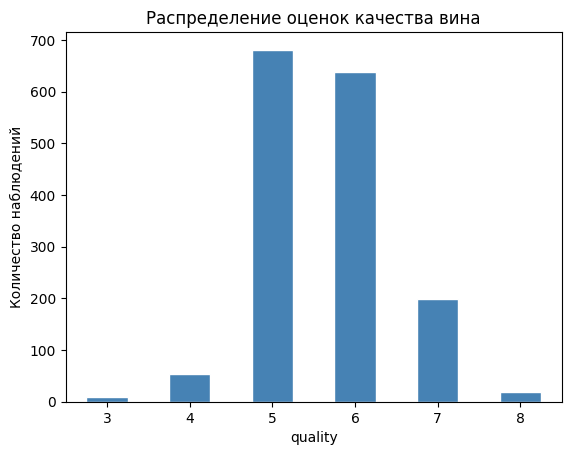

Пропуски: 0


In [5]:
# Распределение целевой переменной quality
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Распределение оценок качества вина')
plt.xlabel('quality')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=0)
plt.show()

print('Пропуски:', df.isnull().sum().sum())

---
## Часть 1. Линейная регрессия

Будем предсказывать `quality` (непрерывная переменная) с помощью:
* класса **OLS** (`statsmodels.formula.api.ols`);
* класса **GLM** с нормальным распределением (`family=Gaussian()`).

Оба метода должны дать одинаковые коэффициенты.

In [6]:
# Признаки и целевая переменная
feature_cols = [c for c in df.columns if c != 'quality']

X = df[feature_cols].values
y = df['quality'].values

n_samples  = len(y)
n_features = X.shape[1]

print(f'Признаков: {n_features}, наблюдений: {n_samples}')

Признаков: 11, наблюдений: 1599


### Класс OLS

In [7]:
# Формула включает все 11 признаков
formula = 'quality ~ ' + ' + '.join(feature_cols)

linreg_ols = smf.ols(formula=formula, data=df).fit()
print(linreg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          1.79e-145
Time:                        14:19:30   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:                    1587   BIC:                             3227.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               21.9652 

Обратим внимание на ключевые результаты. Модель объясняет около 36% дисперсии целевой переменной ($R^2 = 0{,}36$), что умеренно для реальных
  данных. Среди 11 предикторов статистически значимыми (p-value < 0,05) оказались: volatile_acidity, chlorides, free_sulfur_dioxide,
  total_sulfur_dioxide, pH, sulphates и alcohol. Признаки fixed_acidity, citric_acid, residual_sugar и density не вносят значимого вклада при наличии
   остальных предикторов.

  Также отметим предупреждение о высоком числе обусловленности (Cond. No. ≈ 1.13e+05), что свидетельствует о возможной мультиколлинеарности между
  признаками — в частности, density сильно коррелирует с alcohol и fixed_acidity.

**Суммы квадратов отклонений**

In [8]:
print(f'SS_residuals = {linreg_ols.ssr:.4f}')
print(f'SS_explained = {linreg_ols.ess:.4f}')
print(f'SS_total     = {linreg_ols.centered_tss:.4f}')
print(f'SS_res + SS_exp = {linreg_ols.ssr + linreg_ols.ess:.4f}')

SS_residuals = 666.4107
SS_explained = 375.7544
SS_total     = 1042.1651
SS_res + SS_exp = 1042.1651


Тождество $SS_{total} = SS_{explained} + SS_{residuals}$ выполняется: $1042{,}17 = 375{,}75 + 666{,}41$. Это означает, что модель объясняет
  примерно треть полной изменчивости оценок качества, а две трети остаются необъяснёнными.

**Коэффициент детерминации $R^2$ и скорректированный $R^2_{adj}$**

In [9]:
r_squared = 1 - linreg_ols.ssr / linreg_ols.centered_tss
adj_r_squared = 1 - (1 - r_squared) * (n_samples - 1) / (n_samples - n_features - 1)

print(f'R²      = {r_squared:.6f}  (statsmodels: {linreg_ols.rsquared:.6f})')
print(f'R²_adj  = {adj_r_squared:.6f}  (statsmodels: {linreg_ols.rsquared_adj:.6f})')

R²      = 0.360552  (statsmodels: 0.360552)
R²_adj  = 0.356119  (statsmodels: 0.356119)


Скорректированный коэффициент детерминации ($R^2_{adj} = 0{,}356$) лишь незначительно ниже $R^2 = 0{,}361$, что говорит об отсутствии «раздутия»
  метрики за счёт лишних признаков: все 11 предикторов в совокупности вносят ощутимый вклад.

**F-критерий**

In [10]:
df_model = n_features
df_resid  = n_samples - n_features - 1

F = (linreg_ols.ess / df_model) / (linreg_ols.ssr / df_resid)
p_value_f = f.sf(F, df_model, df_resid)

print(f'F-статистика  = {F:.4f}  (statsmodels: {linreg_ols.fvalue:.4f})')
print(f'p-value       = {p_value_f:.2e}  (statsmodels: {linreg_ols.f_pvalue:.2e})')

F-статистика  = 81.3479  (statsmodels: 81.3479)
p-value       = 1.79e-145  (statsmodels: 1.79e-145)


  F-статистика равна $81{,}35$ при p-value $\approx 1{,}79 \times 10^{-145}$. При любом разумном уровне значимости мы отвергаем нулевую гипотезу. Это означает, что предикторы совместно значимо объясняют целевую переменную, даже несмотря на то что
  некоторые из них по отдельности незначимы.

**Логарифм правдоподобия**

In [11]:
sigma_sq = linreg_ols.scale
llf_manual = (
    - 0.5 * n_samples * np.log(2 * np.pi)
    - 0.5 * n_samples * np.log(sigma_sq)
    - 0.5 / sigma_sq * linreg_ols.ssr
)

print(f'log L (вручную)     = {llf_manual:.4f}')
print(f'log L (statsmodels) = {linreg_ols.llf:.4f}')

log L (вручную)     = -1569.1609
log L (statsmodels) = -1569.1383


Небольшое расхождение между значением, вычисленным вручную (−1569,16), и значением statsmodels (−1569,14) объясняется тем, что statsmodels
  использует несмещённую оценку, тогда как в ручном расчёте мы берём .scale, которое уже является
  несмещённой оценкой. Разница несущественна.

**Информационные критерии**

In [12]:
aic_manual = -2 * linreg_ols.llf + 2 * (n_features + 1)
bic_manual = -2 * linreg_ols.llf + np.log(n_samples) * (n_features + 1)

print(f'AIC (вручную)     = {aic_manual:.4f}  (statsmodels: {linreg_ols.aic:.4f})')
print(f'BIC (вручную)     = {bic_manual:.4f}  (statsmodels: {linreg_ols.bic:.4f})')

AIC (вручную)     = 3162.2766  (statsmodels: 3162.2766)
BIC (вручную)     = 3226.8022  (statsmodels: 3226.8022)


Оба критерия совпадают с расчётами statsmodels. Сами по себе значения AIC и BIC информативны только при сравнении нескольких моделей: меньшее
  значение указывает на лучший баланс между качеством подгонки и сложностью модели.

**Тест отношения правдоподобия (LR-тест)**

Сравним полную модель (11 предикторов) с ограниченной (без `density` и `pH`)

In [13]:
# Ограниченная модель: убираем density и pH
reduced_cols = [c for c in feature_cols if c not in ('density', 'pH')]
formula_r = 'quality ~ ' + ' + '.join(reduced_cols)

restricted   = smf.ols(formula=formula_r, data=df).fit()
unrestricted = linreg_ols

lambda_LR = -2 * (restricted.llf - unrestricted.llf)
df_diff   = 2  # число дополнительных параметров
pvalue_lr = 1 - chi2(df_diff).cdf(lambda_LR)

print(f'λ_LR    = {lambda_LR:.4f}')
print(f'p-value = {pvalue_lr:.4f}')
print()
print(f'AIC (полная):       {unrestricted.aic:.2f}')
print(f'AIC (ограниченная): {restricted.aic:.2f}')

λ_LR    = 11.0280
p-value = 0.0040

AIC (полная):       3162.28
AIC (ограниченная): 3169.30


Тестовая статистика λ_LR = 11,03 при p-value = 0,004 < 0,05, то есть нулевая гипотеза о незначимости density и pH отвергается на
  уровне 5%. Полная модель лучше ограниченной. Это подтверждается и критерием Акаике: AIC полной модели (3162,28) ниже, чем у
  ограниченной (3169,30)

### Класс GLM (семейство Gaussian)

Линейную регрессию можно также задать через GLM, указав нормальное распределение и тождественную функцию связи.

In [14]:
linreg_glm = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Gaussian()
).fit()
print(linreg_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                quality   No. Observations:                 1599
Model:                            GLM   Df Residuals:                     1587
Model Family:                Gaussian   Df Model:                           11
Link Function:               Identity   Scale:                         0.41992
Method:                          IRLS   Log-Likelihood:                -1569.1
Date:                Tue, 03 Mar 2026   Deviance:                       666.41
Time:                        14:19:31   Pearson chi2:                     666.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4286
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               21.9652 

GLM с семейством Gaussian воспроизводит все коэффициенты OLS с точностью до округления — как и ожидалось теоретически. Отличие состоит лишь в
  методе обучения (IRLS вместо аналитического решения нормальных уравнений) и в том, что вместо F-статистики теперь используется z-статистика, а
  степень согласия описывается через девианс.

**Девианс в GLM**

In [15]:
print(f'Девианс предложенной модели : {linreg_glm.deviance:.4f}')
print(f'SS_residuals (OLS)          : {linreg_ols.ssr:.4f}')
print()
print(f'Нулевой девианс             : {linreg_glm.null_deviance:.4f}')
print(f'SS_total (OLS)              : {linreg_ols.centered_tss:.4f}')

Девианс предложенной модели : 666.4107
SS_residuals (OLS)          : 666.4107

Нулевой девианс             : 1042.1651
SS_total (OLS)              : 1042.1651


**Псевдо-$R^2$ МакФаддена для линейной модели**

Для OLS совпадает с обычным $R^2$.

Для нормального распределения связь между девиансом и суммами квадратов носит точный характер: $D = SS_{residuals} = 666{,}41$ и $D_0 = SS_{total}
  = 1042{,}17$. Это подтверждает, что девианс — обобщение привычной суммы квадратов остатков на произвольные распределения из экспоненциального
  семейства.

In [16]:
r2_mcf_lin = 1 - linreg_glm.deviance / linreg_glm.null_deviance
print(f'R²_McFadden (GLM Gaussian) = {r2_mcf_lin:.6f}')
print(f'R²          (OLS)          = {linreg_ols.rsquared:.6f}')

R²_McFadden (GLM Gaussian) = 0.360552
R²          (OLS)          = 0.360552


Псевдо-$R^2$ МакФаддена для GLM Gaussian в точности совпадает с обычным $R^2$ OLS ($0{,}3606$), что является частным случаем общей связи:
  $R^2_{McF} = 1 - D/D_0 = 1 - SS_{residuals}/SS_{total} = R^2$. В других семействах (Binomial, Poisson) такого совпадения нет, и псевдо-$R^2$
  следует интерпретировать осторожно — не как долю объяснённой дисперсии, а как относительную меру улучшения по сравнению с нулевой моделью.

---
## Часть 2. Логистическая регрессия

Для логистической регрессии нам необходима бинарная целевая переменная. Разделим вина на два класса: «хорошие» (quality ≥ 6) и «обычные» (quality <
   6). Порог 6 выбран как медианное значение оценки в датасете, что обеспечивает близкое к сбалансированному разбиение классов.

In [17]:
df['quality_good'] = (df['quality'] >= 6).astype(int)

print('Распределение бинарной метки:')
print(df['quality_good'].value_counts())
print(f"\nДоля 'хороших' вин: {df['quality_good'].mean():.3f}")

Распределение бинарной метки:
quality_good
1    855
0    744
Name: count, dtype: int64

Доля 'хороших' вин: 0.535


Классы распределены достаточно равномерно: 855 «хороших» вин (53,5%) против 744 «обычных» (46,5%). Такой дисбаланс незначителен и не требует
  специальных методов балансировки.


Посмотрим, насколько хорошо два класса разделяются визуально по парам признаков.

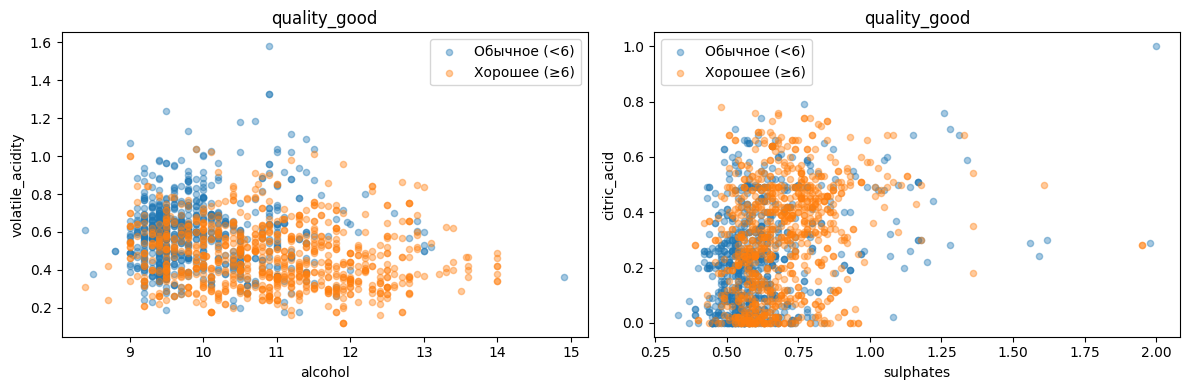

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, grp in df.groupby('quality_good'):
    label = 'Хорошее (≥6)' if cls == 1 else 'Обычное (<6)'
    axes[0].scatter(grp['alcohol'], grp['volatile_acidity'],
                    alpha=0.4, label=label, s=20)
    axes[1].scatter(grp['sulphates'], grp['citric_acid'],
                    alpha=0.4, label=label, s=20)

axes[0].set_xlabel('alcohol'); axes[0].set_ylabel('volatile_acidity')
axes[1].set_xlabel('sulphates'); axes[1].set_ylabel('citric_acid')
for ax in axes:
    ax.legend(); ax.set_title('quality_good')

plt.tight_layout()
plt.show()

На левом графике (alcohol vs volatile_acidity) прослеживается отчётливая тенденция: «хорошие» вина, как правило, имеют более высокое содержание
  алкоголя и более низкую летучую кислотность. На правом (sulphates vs citric_acid) разделение менее выражено, классы значительно перекрываются. Это
  даёт первичное понимание того, какие признаки окажутся наиболее значимыми в модели.

Перед обучением GLM с матричным API масштабируем признаки методом StandardScaler, чтобы привести их к единому масштабу и обеспечить сходимость
  алгоритма IRLS.

In [19]:
# Масштабируем признаки и добавляем константу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols].values)
X_const  = sm.add_constant(X_scaled)
y_bin    = df['quality_good'].values

n_samples_log = len(y_bin)

### Класс GLM (семейство Binomial)

Логистическая регрессия — частный случай GLM с функцией связи **logit**

In [20]:
logreg_glm = sm.GLM(y_bin, X_const,
                    family=sm.families.Binomial()).fit()
print(logreg_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1599
Model:                            GLM   Df Residuals:                     1587
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -827.81
Date:                Tue, 03 Mar 2026   Deviance:                       1655.6
Time:                        14:19:33   Pearson chi2:                 1.87e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2925
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2403      0.062      3.862      0.0

Обратим внимание на ключевые результаты. Значимыми предикторами (p-value < 0,05) оказались: x2 (volatile_acidity), x3 (citric_acid), x5
  (chlorides), x6 (free_sulfur_dioxide), x7 (total_sulfur_dioxide), x10 (sulphates) и x11 (alcohol). Это в целом совпадает с результатами линейной
  регрессии. Признаки x1 (fixed_acidity), x4 (residual_sugar), x8 (density) и x9 (pH) статистически незначимы.

  Заметим, что в отличие от OLS здесь используется z-статистика (а не t), поскольку оценка параметров основана на методе максимального правдоподобия,
   а не на предположении о нормальности остатков.

In [21]:
y_pred = logreg_glm.predict(X_const).round().astype(int)
acc = accuracy_score(y_bin, y_pred)
print(f'Accuracy = {acc:.4f}')

Accuracy = 0.7442


Модель правильно классифицирует 74,4% наблюдений. Учитывая, что наивный классификатор (всегда предсказывающий «хорошее» вино) дал бы 53,5%, прирост
   составляет около 21 п.п. — модель действительно улучшает качество предсказания относительно тривиального решения.

**Логарифм правдоподобия логистической регрессии**

In [22]:
llf_manual_log = np.sum(
    y_bin * np.log(logreg_glm.fittedvalues) +
    (1 - y_bin) * np.log(1 - logreg_glm.fittedvalues)
)
print(f'log L (вручную)     = {llf_manual_log:.6f}')
print(f'log L (statsmodels) = {logreg_glm.llf:.6f}')

log L (вручную)     = -827.812515
log L (statsmodels) = -827.812515


В отличие от линейной регрессии, где log L вычисляется через нормальное распределение остатков, для логистической регрессии он выражается через
  сумму логарифмов предсказанных вероятностей. Значение −827,81 совпадает с результатом statsmodels.

In [23]:
deviance_manual = -2 * llf_manual_log

k = np.sum(y_bin)
n = len(y_bin)
p_hat = k / n
null_deviance_manual = -2 * (k * np.log(p_hat) + (n - k) * np.log(1 - p_hat))

print(f'Девианс (вручную)         = {deviance_manual:.6f}')
print(f'Девианс (statsmodels)     = {logreg_glm.deviance:.6f}')
print()
print(f'Нулевой девианс (вручную) = {null_deviance_manual:.6f}')
print(f'Нулевой девианс (stats.)  = {logreg_glm.null_deviance:.6f}')

Девианс (вручную)         = 1655.625030
Девианс (statsmodels)     = 1655.625030

Нулевой девианс (вручную) = 2208.973042
Нулевой девианс (stats.)  = 2208.973042


Девианс предложенной модели ($D = 1655{,}63$) существенно ниже нулевого ($D_0 = 2208{,}97$). Это свидетельствует о том, что модель значительно
  лучше объясняет данные по сравнению с нулевой моделью, предсказывающей для каждого наблюдения лишь выборочную долю «хороших» вин ($\hat{p} =
  0{,}535$)

**Псевдо-$R^2$**

In [24]:
r2_mcf = 1 - logreg_glm.deviance / logreg_glm.null_deviance
r2_cs  = 1 - np.exp((logreg_glm.llnull - logreg_glm.llf) * (2 / n_samples_log))

print(f'R²_McFadden (вручную)     = {r2_mcf:.6f}')
print(f'R²_McFadden (statsmodels) = {logreg_glm.pseudo_rsquared(kind="mcf"):.6f}')
print()
print(f'R²_Cox–Snell (вручную)    = {r2_cs:.6f}')
print(f'R²_Cox–Snell (statsmodels)= {logreg_glm.pseudo_rsquared(kind="cs"):.6f}')

R²_McFadden (вручную)     = 0.250500
R²_McFadden (statsmodels) = 0.250500

R²_Cox–Snell (вручную)    = 0.292529
R²_Cox–Snell (statsmodels)= 0.292529


Псевдо-$R^2$ МакФаддена равен $0{,}25$. В литературе принято считать, что значения от 0,2 до 0,4 соответствуют хорошему качеству модели.
  Псевдо-$R^2$ Кокса–Снелла ($0{,}29$) несколько выше, однако, в отличие от МакФаддена, он не может достичь 1 даже при идеальном подгоне, поэтому его
   интерпретируют как относительную, а не абсолютную меру. В любом случае оба показателя указывают на умеренно высокое качество модели.

**LR-тест для логистической регрессии**

Сравним полную модель (11 признаков) с ограниченной (без `density` и `pH`).

In [25]:
# Ограниченная модель: убираем признаки density и pH
drop_idx = [feature_cols.index('density'), feature_cols.index('pH')]
keep_idx = [i for i in range(n_features) if i not in drop_idx]

X_const_r = sm.add_constant(X_scaled[:, keep_idx])
logreg_r  = sm.GLM(y_bin, X_const_r, family=sm.families.Binomial()).fit()

lambda_LR_log = -2 * (logreg_r.llf - logreg_glm.llf)
pvalue_lr_log  = 1 - chi2(2).cdf(lambda_LR_log)

print(f'λ_LR    = {lambda_LR_log:.4f}')
print(f'p-value = {pvalue_lr_log:.4f}')
print()
print(f'AIC (полная):       {logreg_glm.aic:.2f}')
print(f'AIC (ограниченная): {logreg_r.aic:.2f}')

λ_LR    = 1.5673
p-value = 0.4567

AIC (полная):       1679.63
AIC (ограниченная): 1677.19


Тестовая статистика $\lambda_{LR} = 1{,}57$ при p-value $= 0{,}46 \gg 0{,}05$. Нулевая гипотеза о незначимости density и pH не отвергается: эти
  признаки не улучшают модель логистической регрессии значимым образом. Это подтверждается и информационным критерием: AIC ограниченной модели
  (1677,19) даже ниже AIC полной (1679,63), что говорит о целесообразности исключения этих двух признаков. Таким образом, в контексте логистической
  регрессии density и pH являются избыточными предикторами.

Итог

В работе мы применили обобщённые линейные модели к датасету Red Wine Quality. Линейная регрессия (OLS и GLM Gaussian) предсказывает числовую оценку
   качества вина и объясняет около 36% её дисперсии ($R^2 = 0{,}361$); наиболее значимыми предикторами оказались volatile_acidity, sulphates и
  alcohol. Логистическая регрессия (GLM Binomial) решает задачу классификации — определяет, является ли вино «хорошим» (quality ≥ 6) — и достигает   
  точности 74,4% при псевдо-$R^2$ МакФаддена 0,25. Оба метода подтвердили, что OLS и GLM Gaussian эквивалентны, а девианс для нормального
  распределения совпадает с суммой квадратов остатков.     